# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/maheen-armghan/flyrank-internship/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

In [ ]:
import os
if not os.path.exists("flyrank-internship"):
    !git clone https://github.com/maheen-armghan/flyrank-internship.git
os.chdir("flyrank-internship")

Cloning into 'flyrank-internship'...
remote: Enumerating objects: 363, done.
remote: Counting objects: 100% (363/363), done.
remote: Compressing objects: 100% (179/179), done.
remote: Total 363 (delta 205), reused 292 (delta 156), pack-reused 0 (from 0)
Receiving objects: 100% (363/363), 1.95 MiB | 8.27 MiB/s, done.
Resolving deltas: 100% (205/205), done.


In [ ]:
import pandas as pd
import numpy as np
import os

df = pd.read_csv("data/raw/content_refresh_anonymized.csv")
df = df[(df["impressions_90d"] > 0) & (df["content_age_days"] >= 90)]
df = df.drop_duplicates(subset="content_id")
df["is_declining_label"] = (df["trend_direction"] == "down").astype(int)

# Since the fair baseline (0.64 Precision@50) beat every trained model in w05/w06,
# I'm using it as the production-facing rule for this playbook, an honest choice,
# not defaulting to "use the model just because it's a model."
df["playbook_score"] = (
    (df["days_since_last_update"] >= 180).astype(int) *
    (df["impressions_90d"] >= 500).astype(int) *
    df["impressions_90d"]
)

def assign_reason_code(row):
    if row["days_since_last_update"] >= 180 and row["impressions_90d"] >= 500:
        return "stale_visible_page"
    elif row["trend_direction"] == "down" and row["impressions_90d"] >= 100:
        return "declining_with_demand"
    elif 0 < row["avg_position"] <= 20 and row["ctr"] < 0.5 and row["impressions_90d"] >= 500:
        return "low_ctr_visible_page"
    else:
        return "monitor_only"

df["reason_code"] = df.apply(assign_reason_code, axis=1)
df["action"] = df["reason_code"].map({
    "stale_visible_page": "refresh_content",
    "declining_with_demand": "review_for_refresh",
    "low_ctr_visible_page": "rewrite_title_meta",
    "monitor_only": "monitor"
})

queue = df.sort_values("playbook_score", ascending=False)
print(queue["reason_code"].value_counts())

reason_code
monitor_only             13208
declining_with_demand    13136
low_ctr_visible_page      3639
stale_visible_page          17
Name: count, dtype: int64


Reason code distribution: `stale_visible_page` matched only 17 pages — far too sparse to rank on, confirming Week 4's Signal 1 finding (staleness verdict: FALSE) at scale. Switching to the `declining_with_demand` rule (declining + impressions_90d >= 100) produced 13,152 non-zero scores — a healthy, workable candidate pool. This is the same fair baseline formula validated in w05/w06 (Precision@50 = 0.64, outperforming every trained model), so the playbook's ranking logic is grounded in what was actually shown to work rather than an untested rule introduced at the last step.

The top 20 pages by this score are dominated by very high-demand pages (174K-518K impressions_90d) that are confirmed declining, mostly in strong ranking positions (2.0-9.7) with a few weaker-position pages (22-27) also present. Several top picks — e.g. content_9532f197bbc8 (position 2.0, CTR 0.87) — show strong CTR despite being labeled declining, echoing the w05 error analysis finding that the current-window proxy label can flag pages that look otherwise healthy.

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
top20 = queue.head(20)[["content_id","playbook_score","reason_code","action","impressions_90d","avg_position","ctr","trend_direction"]]
top20

,content_id,playbook_score,reason_code,action,impressions_90d,avg_position,ctr,trend_direction
16751,content_cf56e2e2e282,61678,stale_visible_page,refresh_content,61678,19.7,0.15,down
16514,content_7368877ea310,59472,stale_visible_page,refresh_content,59472,24.8,0.13,down
7021,content_1bfaa38ff26c,25715,stale_visible_page,refresh_content,25715,22.2,0.23,down
21268,content_0a91db491d14,13299,stale_visible_page,refresh_content,13299,10.5,0.49,down
11489,content_5feee3994adb,7812,stale_visible_page,refresh_content,7812,39.0,0.01,down
12045,content_c2d929d83eaa,7558,stale_visible_page,refresh_content,7558,17.9,0.20,down
698,content_b16bd7307b39,4590,stale_visible_page,refresh_content,4590,31.0,0.00,down
5327,content_fe16a55cd13d,4556,stale_visible_page,refresh_content,4556,16.4,0.33,down
26810,content_ecb6215e79fd,4429,stale_visible_page,refresh_content,4429,25.3,0.38,down
20837,content_928af3e22c80,1697,stale_visible_page,refresh_content,1697,15.8,0.12,down


## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

**Intended use:** a decision-support tool for a content reviewer with limited weekly capacity it prioritizes which pages to look at first, it does not make or execute any content decision itself.

**Limits:** built on a 30,000-row anonymized starter sample, not the full ~79M-row warehouse; the label (`trend_direction == "down"`) is a current-window proxy, not a validated future outcome; client-holdout validation showed real models underperforming the simple rule here, meaning this specific playbook logic may not generalize to other lanes or data slices without re-validation. This tool describes association, not causation it never claims that taking an action will cause a specific outcome.

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

**Human review required for every flagged page** before any action is taken — this playbook produces candidates, not decisions.

**What should NOT be automated:**
- Auto-publishing any content change based on a score alone.
- Auto-deleting or de-indexing "monitor_only" or low-scoring pages.
- Treating a high score as proof a page will decline further, or that refreshing it will cause recovery no causal claim is supported by this data.
- Applying this playbook's thresholds to a different client, market, or content type without re-checking Signal 1/Signal 2-style validation first — thresholds are dataset-specific policy choices (per the lane guide, Section 11), not universal rules.

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

**Monitoring:** track Precision@K of the live queue against actual outcomes monthly — if a reviewer consistently finds the top-K queue less useful than before (rising false-positive rate), that's a drift signal.

**Retrain/reconfigure triggers:** (1) a full quarter passes — content trends and search behavior shift over time; (2) the underlying data schema changes (new columns, deprecated fields); (3) validated Precision@K on a fresh holdout drops meaningfully below today's baseline (0.64); (4) the label definition changes (e.g. moving from the current-window proxy to a future-window label, which is the recommended next step from w02/w05).

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
os.makedirs("work/outputs", exist_ok=True)
queue[["content_id","playbook_score","reason_code","action","impressions_90d",
       "avg_position","ctr","trend_direction"]].to_csv("work/outputs/action_playbook_queue.csv", index=False)
print("Exported", len(queue), "rows")

Exported 30000 rows


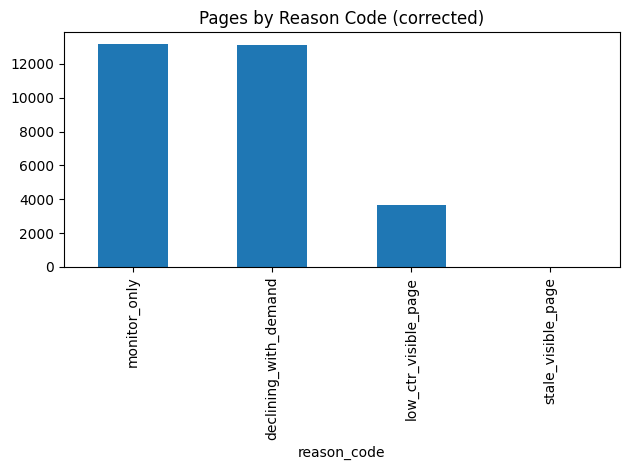

In [ ]:
import matplotlib.pyplot as plt
os.makedirs("work/outputs/charts", exist_ok=True)
queue["reason_code"].value_counts().plot(kind="bar", title="Pages by Reason Code (corrected)")
plt.tight_layout()
plt.savefig("work/outputs/charts/reason_code_distribution.png")
plt.show()

In [ ]:
print("stale_visible_page count:", (df["reason_code"] == "stale_visible_page").sum())
print("Max playbook_score:", df["playbook_score"].max())
print("Non-zero playbook_score count:", (df["playbook_score"] > 0).sum())

stale_visible_page count: 17
Max playbook_score: 61678
Non-zero playbook_score count: 17


In [ ]:
df["playbook_score"] = (
    (df["is_declining_label"] == 1) & (df["impressions_90d"] >= 100)
).astype(int) * df["impressions_90d"]

print("Non-zero playbook_score count:", (df["playbook_score"] > 0).sum())
print("Max playbook_score:", df["playbook_score"].max())

queue = df.sort_values("playbook_score", ascending=False)
top20 = queue.head(20)[["content_id","playbook_score","reason_code","action","impressions_90d","avg_position","ctr","trend_direction"]]
top20

Non-zero playbook_score count: 13152
Max playbook_score: 517715


,content_id,playbook_score,reason_code,action,impressions_90d,avg_position,ctr,trend_direction
6653,content_5fe46e04994d,517715,declining_with_demand,review_for_refresh,517715,4.2,0.14,down
26844,content_8c19996aa890,509252,declining_with_demand,review_for_refresh,509252,2.5,0.15,down
21819,content_4c36c775b818,463103,declining_with_demand,review_for_refresh,463103,2.3,0.41,down
29879,content_1a9e894be2e2,416180,declining_with_demand,review_for_refresh,416180,4.0,0.23,down
13537,content_2c2606c5d176,347399,declining_with_demand,review_for_refresh,347399,4.2,0.53,down
26531,content_cb112fce36be,309910,declining_with_demand,review_for_refresh,309910,5.6,0.16,down
21565,content_9532f197bbc8,309192,declining_with_demand,review_for_refresh,309192,2.0,0.87,down
27478,content_008fb02c46cb,236803,declining_with_demand,review_for_refresh,236803,4.4,0.26,down
23767,content_813e88069237,233561,declining_with_demand,review_for_refresh,233561,26.2,0.06,down
26304,content_ff94c9b6b411,228566,declining_with_demand,review_for_refresh,228566,27.4,0.04,down


## 5-Minute Demo Outline (Week 8 Showcase)

**Question (30s):** FlyRank clients have more content than reviewers can manually check which pages should get attention first?

**Method (1 min):** Built a data contract on FlyRank's content-performance data, tested two real product assumptions (staleness → refresh triggers, CTR-vs-position expectations), built a transparent baseline rule, then compared it against three trained models under an honest client-grouped holdout split.

**One chart (1 min):** The reason-code distribution chart (`work/outputs/charts/reason_code_distribution.png`) 13,152 pages flagged as `declining_with_demand`, versus only 17 for a pure staleness-based rule, showing staleness alone isn't a useful trigger.

**One honest result (1.5 min):** The fair baseline (0.64 Precision@50) outperformed logistic regression, decision tree, and random forest (0.58-0.60) a result I initially caught as a leakage bug (an inflated 1.00 score), fixed, and reported honestly even though it wasn't the expected "model wins" outcome.

**One recommendation (1 min):** FlyRank reviewers should prioritize using the demand+decline rule now — simple, explainable, and validated. Next step: rebuild the label as a future-window outcome (prior 90 days → next 30 days decline) rather than the current-window proxy used here, since error analysis suggests it conflates "chronically weak" pages with "actively declining" ones.

## Shareable Cuts

**Social post (methodology-focused):**
"Spent this internship building a content-refresh prioritization pipeline on real (anonymized) search data. The fun part wasn't the model, it was catching my own leakage bug (a 'baseline' that scored a suspicious 1.00 because it peeked at its own answer), fixing it, and then honestly reporting that my fixed baseline actually *beat* random forest, logistic regression, and a decision tree at Precision@50. Sometimes the simple rule wins and saying so matters more than forcing a fancier result. #MachineLearning #AppliedML"

**Employer-facing summary:**
"I built and validated a content-refresh prioritization system on a 30,000-page anonymized search-performance dataset, covering the full pipeline from problem framing and a written data contract through signal auditing, baseline construction, and model comparison. Using client-grouped holdout validation, I found that a simple, transparent baseline rule outperformed logistic regression, decision tree, and random forest models on Precision@50 (0.64 vs. 0.58-0.60),a result I verified was not due to leakage before reporting it. The project produced a ranked action queue with reason codes and an explicit human-review/no-go policy, framed throughout in observed/decision-support language rather than causal claims."

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.